In [1]:
#SCOPETYPE = 'OPENADC' #change as per your board specification
SCOPETYPE = 'OPENADC'
#PLATFORM = 'CWLITEARM'#change as per your board specification
PLATFORM = 'CW308_STM32F3'
SS_VER = 'SS_VER_1_1' #Do not change

In [2]:
%run "../../Setup_Scripts/Setup_Generic.ipynb"

INFO: Found ChipWhisperer😍
scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 6067643                   to 16811794                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 29538471                  to 29538459                 
scope.clock.adc_rate                     changed from 29538471.0                to 29538459.0        

We'll probably crash the target a few times while we're trying some glitching. Create a function to reset the target:

In [3]:
# Basically "refresh" for a board just like we do in our computer before proceeding to work.
#def reboot_flush():
 #   scope.io.nrst = False
  #  time.sleep(0.05)
   # scope.io.nrst = "high_z"
    #time.sleep(0.05)
    
    # Flush garbage too
    #target.flush()

In [4]:
import chipwhisperer as cw
from tqdm import trange
import numpy as np
import time

# 1. Connect to the Scope and Target
target = cw.target(scope)
scope.default_setup()
# Set the lengths for the PRESENT cipher!
target.output_len = 8
# 2. Flash your NEW firmware
firmware_path = "/home/pankaj/Documents/cw_crypto/chipwhisperer/firmware/mcu/simpleserial-present/simpleserial-present-CW308_STM32F3.hex"
cw.program_target(scope, cw.programmers.STM32FProgrammer, firmware_path)

Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 5583 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 5583 bytes


In [5]:
# 3. Reset the target by toggling the NRST pin
scope.io.nrst = 'low'
time.sleep(0.05)
scope.io.nrst = 'high_z'
time.sleep(0.05)
target.flush()

# 4. Set up the 10-byte PRESENT-80 Key
key = bytearray([0xAA, 0xBB, 0xCC, 0xDD, 0xEE, 0xFF, 0x11, 0x22, 0x33, 0x44])

# 5. Capture Loop
num_traces = 200
traces = []

print("Starting Capture...")
for i in trange(num_traces):
    # Generate a random 8-byte plaintext
    pt = bytearray(np.random.randint(0, 256, 8, dtype=np.uint8))
    
    # Send Key and Plaintext, and capture the power trace
    trace = cw.capture_trace(scope, target, pt, key)
    
    if trace is None:
        print(f"Capture failed at trace {i}")
        continue
        
    traces.append(trace)

print(f"Successfully captured {len(traces)} traces!")

# 6. Disconnect hardware when finished
scope.dis()
target.dis()


Starting Capture...


100%|█████████████████████████████████████████| 200/200 [00:05<00:00, 36.37it/s]

Successfully captured 200 traces!


In [6]:
import numpy as np

# 1. Convert captured traces to numpy arrays for fast vectorized math
trace_array = np.array([trace.wave for trace in traces])
textin_array = np.array([trace.textin for trace in traces])
num_traces, num_points = trace_array.shape

# 2. PRESENT S-Box and Hamming Weight Table
sbox = [0xC, 0x5, 0x6, 0xB, 0x9, 0x0, 0xA, 0xD, 0x3, 0xE, 0xF, 0x8, 0x4, 0x7, 0x1, 0x2]
HW = [bin(x).count('1') for x in range(16)]

recovered_key_nibbles = []
print("Starting Fast CPA Attack on PRESENT...\n")

# Loop through all 16 nibbles (64-bits) of the subkey
for nibble_idx in range(16):
    max_cpa = 0
    best_guess = 0
    
    # Test all 16 possible values for a 4-bit nibble
    for guess in range(16):
        # Build the hypothetical power model (Hamming Weight) for this guess
        hws = np.zeros(num_traces)
        for t in range(num_traces):
            pt_byte = textin_array[t][nibble_idx // 2]
            # Extract the correct High or Low 4-bit nibble from the plaintext byte
            pt_nibble = (pt_byte >> 4) if (nibble_idx % 2 == 0) else (pt_byte & 0x0F)
            
            # PRESENT Round 1: AddKey -> Sbox
            hws[t] = HW[sbox[pt_nibble ^ guess]]
            
        # Fast Numpy Vectorized Correlation across all trace points simultaneously
        hws_c = hws - hws.mean()
        traces_c = trace_array - trace_array.mean(axis=0)
        
        cov = np.dot(hws_c, traces_c)
        hw_std = np.sqrt(np.sum(hws_c**2))
        tr_std = np.sqrt(np.sum(traces_c**2, axis=0))
        
        # Avoid division by zero
        tr_std[tr_std == 0] = 1 
        if hw_std == 0: hw_std = 1
            
        corr = np.abs(cov / (hw_std * tr_std))
        cpa_max = np.max(corr)
        
        # Record the guess with the highest correlation peak
        if cpa_max > max_cpa:
            max_cpa = cpa_max
            best_guess = guess
            
    recovered_key_nibbles.append(best_guess)
    print(f"Nibble {nibble_idx:2d} -> Recovered: {hex(best_guess)} (Confidence: {max_cpa:.4f})")

# Reconstruct the 64-bit recovered key
recovered_key = [(recovered_key_nibbles[i] << 4) | recovered_key_nibbles[i+1] for i in range(0, 16, 2)]

# Get the ACTUAL first 8 bytes of the key used during capture
actual_key = list(traces[0].key[:8])

print("\n--- ATTACK RESULTS ---")
print("Expected First 8 Bytes :", [hex(b) for b in actual_key])
print("Recovered First 8 Bytes:", [hex(b) for b in recovered_key])

if actual_key == recovered_key:
    print("\n✅ SUCCESS! The recovered key perfectly matches the real key!")
else:
    print("\n❌ FAILED! Some nibbles were incorrect. Try capturing more traces to eliminate ghost peaks.")


Starting Fast CPA Attack on PRESENT...

Nibble  0 -> Recovered: 0xa (Confidence: 0.7902)
Nibble  1 -> Recovered: 0xa (Confidence: 0.6657)
Nibble  2 -> Recovered: 0xb (Confidence: 0.6885)
Nibble  3 -> Recovered: 0xb (Confidence: 0.6870)
Nibble  4 -> Recovered: 0xc (Confidence: 0.6914)
Nibble  5 -> Recovered: 0xc (Confidence: 0.7216)
Nibble  6 -> Recovered: 0xd (Confidence: 0.6003)
Nibble  7 -> Recovered: 0xd (Confidence: 0.6513)
Nibble  8 -> Recovered: 0xe (Confidence: 0.5378)
Nibble  9 -> Recovered: 0xe (Confidence: 0.6880)
Nibble 10 -> Recovered: 0xf (Confidence: 0.6235)
Nibble 11 -> Recovered: 0xf (Confidence: 0.6363)
Nibble 12 -> Recovered: 0x1 (Confidence: 0.6637)
Nibble 13 -> Recovered: 0x1 (Confidence: 0.6620)
Nibble 14 -> Recovered: 0x2 (Confidence: 0.6725)
Nibble 15 -> Recovered: 0x2 (Confidence: 0.6258)

--- ATTACK RESULTS ---
Expected First 8 Bytes : ['0xaa', '0xbb', '0xcc', '0xdd', '0xee', '0xff', '0x11', '0x22']
Recovered First 8 Bytes: ['0xaa', '0xbb', '0xcc', '0xdd', '0xe

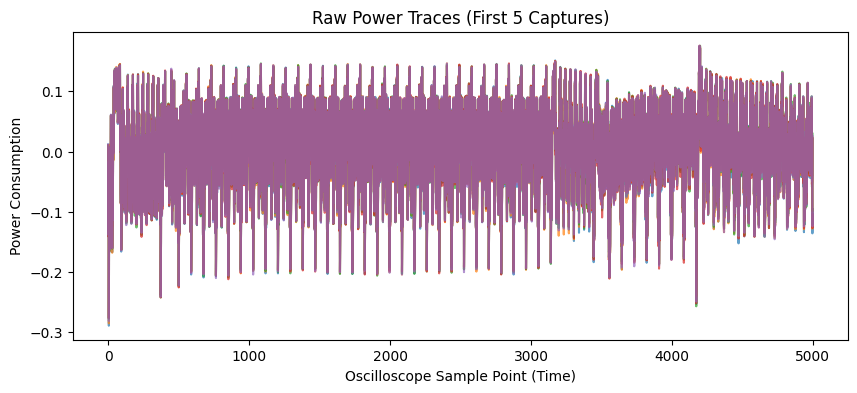

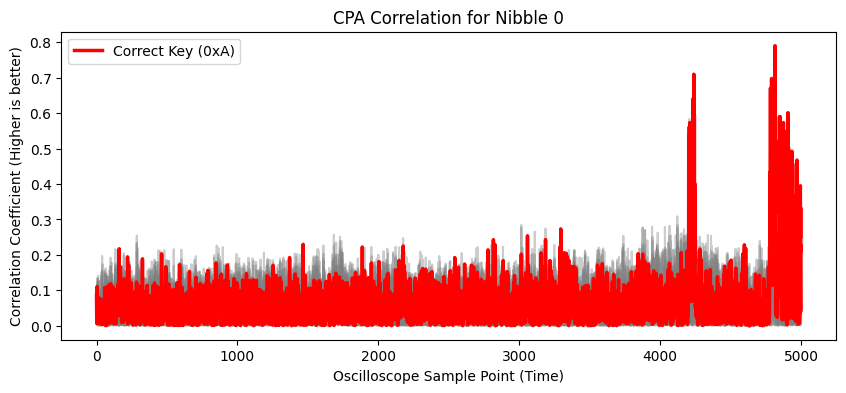

In [7]:
import matplotlib.pyplot as plt

# ==========================================
# GRAPH 1: Visualize the Raw Power Traces
# ==========================================
plt.figure(figsize=(10, 4))
# We will just plot the first 5 traces so the graph isn't too cluttered
for i in range(5):
    plt.plot(trace_array[i], alpha=0.7)
    
plt.title("Raw Power Traces (First 5 Captures)")
plt.xlabel("Oscilloscope Sample Point (Time)")
plt.ylabel("Power Consumption")
plt.show()


# ==========================================
# GRAPH 2: Visualize the CPA Attack (Nibble 0)
# ==========================================
plt.figure(figsize=(10, 4))
nibble_idx = 0
correct_guess = 0xA  # Because our key starts with 0xAA

for guess in range(16):
    # Recalculate correlation for this specific guess
    hws = np.zeros(num_traces)
    for t in range(num_traces):
        pt_byte = textin_array[t][nibble_idx // 2]
        pt_nibble = pt_byte >> 4  # High nibble
        hws[t] = HW[sbox[pt_nibble ^ guess]]
        
    hws_c = hws - hws.mean()
    traces_c = trace_array - trace_array.mean(axis=0)
    
    cov = np.dot(hws_c, traces_c)
    hw_std = np.sqrt(np.sum(hws_c**2))
    tr_std = np.sqrt(np.sum(traces_c**2, axis=0))
    tr_std[tr_std == 0] = 1
    if hw_std == 0: hw_std = 1
        
    corr = np.abs(cov / (hw_std * tr_std))
    
    # Draw the correct guess in RED, and wrong guesses in GRAY
    if guess == correct_guess:
        plt.plot(corr, color='red', linewidth=2.5, label=f"Correct Key (0x{guess:X})", zorder=10)
    else:
        plt.plot(corr, color='gray', alpha=0.4)

plt.title("CPA Correlation for Nibble 0")
plt.xlabel("Oscilloscope Sample Point (Time)")
plt.ylabel("Correlation Coefficient (Higher is better)")
plt.legend()
plt.show()


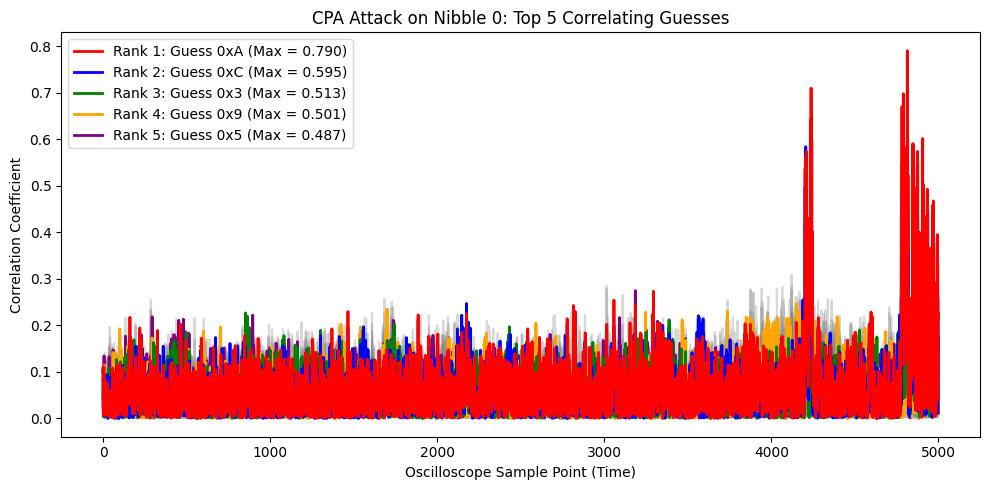

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
nibble_idx = 0

# A list to store the results for all 16 guesses
results = []

for guess in range(16):
    hws = np.zeros(num_traces)
    for t in range(num_traces):
        pt_byte = textin_array[t][nibble_idx // 2]
        pt_nibble = pt_byte >> 4  # High nibble
        hws[t] = HW[sbox[pt_nibble ^ guess]]
        
    hws_c = hws - hws.mean()
    traces_c = trace_array - trace_array.mean(axis=0)
    
    cov = np.dot(hws_c, traces_c)
    hw_std = np.sqrt(np.sum(hws_c**2))
    tr_std = np.sqrt(np.sum(traces_c**2, axis=0))
    tr_std[tr_std == 0] = 1
    if hw_std == 0: hw_std = 1
        
    corr = np.abs(cov / (hw_std * tr_std))
    
    max_corr = np.max(corr)
    results.append((guess, max_corr, corr))

# Sort the results by the maximum correlation, from highest to lowest
results.sort(key=lambda x: x[1], reverse=True)

# Colors for the top 5 guesses
colors = ['red', 'blue', 'green', 'orange', 'purple']

# Plot them all
for rank, (guess, max_corr, corr) in enumerate(results):
    if rank < 5:
        # Plot the Top 5 with unique colors and add them to the legend
        plt.plot(corr, color=colors[rank], linewidth=2.0, 
                 label=f"Rank {rank+1}: Guess 0x{guess:X} (Max = {max_corr:.3f})", zorder=10-rank)
    else:
        # Plot the remaining bad guesses in light gray
        plt.plot(corr, color='gray', alpha=0.3, zorder=0)

plt.title(f"CPA Attack on Nibble {nibble_idx}: Top 5 Correlating Guesses")
plt.xlabel("Oscilloscope Sample Point (Time)")
plt.ylabel("Correlation Coefficient")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [9]:
from tqdm import trange

# ==========================================
# PRESENT-80 Python Implementation
# ==========================================
def permute(source):
    P = [0,16,32,48,1,17,33,49,2,18,34,50,3,19,35,51,
         4,20,36,52,5,21,37,53,6,22,38,54,7,23,39,55,
         8,24,40,56,9,25,41,57,10,26,42,58,11,27,43,59,
         12,28,44,60,13,29,45,61,14,30,46,62,15,31,47,63]
    permutation = 0
    for i in range(64):
        bit = (source >> (63 - i)) & 1
        permutation |= (bit << (63 - P[i]))
    return permutation

def generate_subkeys(master_key_bytes):
    sbox = [0xC,0x5,0x6,0xB,0x9,0x0,0xA,0xD,0x3,0xE,0xF,0x8,0x4,0x7,0x1,0x2]
    subkeys = []
    keyHigh = 0
    for i in range(8):
        keyHigh = (keyHigh << 8) | master_key_bytes[i]
    keyLow = (master_key_bytes[8] << 8) | master_key_bytes[9]
    subkeys.append(keyHigh)
    
    for i in range(1, 32):
        temp1, temp2 = keyHigh, keyLow
        keyHigh = ((temp1 << 61) & 0xFFFFFFFFFFFFFFFF) | (temp2 << 45) | (temp1 >> 19)
        keyLow = (temp1 >> 3) & 0xFFFF
        temp = sbox[keyHigh >> 60]
        keyHigh = (keyHigh & 0x0FFFFFFFFFFFFFFF) | (temp << 60)
        keyLow ^= ((i & 0x01) << 15)
        keyHigh ^= (i >> 1)
        subkeys.append(keyHigh)
    return subkeys

def present_encrypt(pt_bytes, master_key_bytes):
    sbox = [0xC,0x5,0x6,0xB,0x9,0x0,0xA,0xD,0x3,0xE,0xF,0x8,0x4,0x7,0x1,0x2]
    subkeys = generate_subkeys(master_key_bytes)
    
    state = 0
    for i in range(8): state = (state << 8) | pt_bytes[i]
        
    for i in range(31):
        state ^= subkeys[i]
        new_state = 0
        for j in range(16):
            nibble = (state >> (j*4)) & 0xF
            new_state |= (sbox[nibble] << (j*4))
        state = permute(new_state)
    state ^= subkeys[31]
    
    out = bytearray(8)
    for i in range(7, -1, -1):
        out[i] = state & 0xFF
        state >>= 8
    return out

# ==========================================
# 16-Bit Brute Force Attack
# ==========================================

# We use the 64-bit key you recovered in the previous step
# (Make sure 'recovered_key' is available from the previous cell!)
recovered_64_bits = recovered_key 

# Take the Plaintext and Ciphertext from your first captured trace
target_pt = traces[0].textin
target_ct = traces[0].textout

print(f"Target Plaintext  : {[hex(b) for b in target_pt]}")
print(f"Target Ciphertext : {[hex(b) for b in target_ct]}\n")
print("Starting 16-bit Brute Force... (This will take a few seconds)")

found = False
for guess in trange(65536):
    guess_byte_1 = guess >> 8
    guess_byte_2 = guess & 0xFF
    
    # Combine the 64-bit recovered key with our 16-bit guess
    full_key = bytearray(recovered_64_bits + [guess_byte_1, guess_byte_2])
    
    # Encrypt the plaintext using the guess
    ct = present_encrypt(target_pt, full_key)
    
    # Check if the output matches the real ciphertext from the oscilloscope!
    if ct == target_ct:
        print("\n✅ MATCH FOUND!")
        print(f"The final two bytes of the secret key are: {hex(guess_byte_1)}, {hex(guess_byte_2)}")
        print("\n🏆 FULL 80-BIT RECOVERED KEY:")
        print([hex(b) for b in full_key])
        found = True
        break

if not found:
    print("\n❌ Failed to find the key. Ensure the first 64 bits were recovered correctly without Ghost Peaks.")


Target Plaintext  : ['0x70', '0xa2', '0x9', '0x49', '0x3d', '0x3e', '0xde', '0x28']
Target Ciphertext : ['0x1c', '0xe4', '0x5c', '0x4f', '0xfa', '0xad', '0x95', '0x75']

Starting 16-bit Brute Force... (This will take a few seconds)


 20%|███████                            | 13124/65536 [00:05<00:21, 2426.34it/s]


✅ MATCH FOUND!
The final two bytes of the secret key are: 0x33, 0x44

🏆 FULL 80-BIT RECOVERED KEY:
['0xaa', '0xbb', '0xcc', '0xdd', '0xee', '0xff', '0x11', '0x22', '0x33', '0x44']


In [17]:
def get_round2_input(pt_array, first_subkey_bytes):
    # Ensure rk1 is a standard Python int
    rk1 = 0
    for b in first_subkey_bytes:
        rk1 = (rk1 << 8) | int(b)
        
    round2_inputs = []
    for pt in pt_array:
        # Convert pt bytes to a standard Python 64-bit int
        state = 0
        for b in pt: 
            state = (state << 8) | int(b)
        
        # --- Round 1 ---
        # Explicitly cast to int to prevent NumPy from complaining about ufuncs
        state = int(state) ^ int(rk1)
        
        # S-Box Layer
        new_state = 0
        for j in range(16):
            nibble = (state >> (j*4)) & 0xF
            new_state |= (int(sbox[nibble]) << (j*4))
        
        # pLayer (Permutation)
        state = permute(new_state)
        
        # This 'state' is now exactly what enters Round 2
        round2_inputs.append(state)
        
    return np.array(round2_inputs, dtype=object) # Use object dtype for large ints

# Now call it again
r2_data = get_round2_input(textin_array, recovered_key)
print("Success! Round 2 inputs calculated.")

Success! Round 2 inputs calculated.


In [19]:
def visualize_trace(pt, subkey, sbox, p_func):
    def to_nibbles(val):
        return [f"{ (val >> (60-i*4)) & 0xF :X}" for i in range(16)]

    state = 0
    for b in pt: state = (state << 8) | int(b)
    rk1 = 0
    for b in subkey: rk1 = (rk1 << 8) | int(b)

    print(f"{'STAGE':<20} | {'64-BIT HEX STATE':<18} | {'NIBBLE VIEW'}")
    print("-" * 75)
    print(f"{'1. Plaintext':<20} | {state:016x} | {' '.join(to_nibbles(state))}")
    
    state ^= rk1
    print(f"{'2. After XOR':<20} | {state:016x} | {' '.join(to_nibbles(state))}")
    
    new_state = 0
    for j in range(16):
        nibble = (state >> (j*4)) & 0xF
        new_state |= (sbox[nibble] << (j*4))
    state = new_state
    print(f"{'3. After S-Box':<20} | {state:016x} | {' '.join(to_nibbles(state))}")
    
    state = p_func(state)
    print(f"{'4. After Permute':<20} | {state:016x} | {' '.join(to_nibbles(state))}")

# Visualize for the first trace
visualize_trace(textin_array[0], recovered_key, sbox, permute)

STAGE                | 64-BIT HEX STATE   | NIBBLE VIEW
---------------------------------------------------------------------------
1. Plaintext         | 70a209493d3ede28 | 7 0 A 2 0 9 4 9 3 D 3 E D E 2 8
2. After XOR         | da19c594d3c1cf0a | D A 1 9 C 5 9 4 D 3 C 1 C F 0 A
3. After S-Box       | 7f5e40e97b4542cf | 7 F 5 E 4 0 E 9 7 B 4 5 4 2 C F
4. After Permute     | 5343fabbd2c5e1d1 | 5 3 4 3 F A B B D 2 C 5 E 1 D 1


In [21]:
# The missing bits (k15...k0) have rotated into the Round 2 subkey.
# We only need to attack the first 4 nibbles of Round 2 to get those 16 bits.

recovered_missing_nibbles = []

print("Starting CPA on Round 2 to recover missing 16 bits...")

for nibble_idx in range(4): # Attacking the first 16 bits of the Round 2 subkey
    max_cpa = 0
    best_guess = 0
    
    for guess in range(16):
        hws = np.zeros(num_traces)
        for t in range(num_traces):
            # Extract the nibble from the Round 2 input data
            # (Note: we use bit-shifting to get the specific 4-bit chunk)
            r2_nibble = (r2_data[t] >> (60 - nibble_idx*4)) & 0xF
            
            # Model: HW of the S-Box output in Round 2
            hws[t] = HW[sbox[r2_nibble ^ guess]]
            
        # Standard Correlation Math
        hws_c = hws - hws.mean()
        traces_c = trace_array - trace_array.mean(axis=0)
        cov = np.dot(hws_c, traces_c)
        hw_std = np.sqrt(np.sum(hws_c**2))
        tr_std = np.sqrt(np.sum(traces_c**2, axis=0))
        
        tr_std[tr_std == 0] = 1
        corr = np.abs(cov / (hw_std * tr_std))
        cpa_max = np.max(corr)
        
        if cpa_max > max_cpa:
            max_cpa = cpa_max
            best_guess = guess
            
    recovered_missing_nibbles.append(best_guess)
    print(f"R2 Nibble {nibble_idx} -> Recovered: {hex(best_guess)} (Confidence: {max_cpa:.4f})")

# Combine the 4 nibbles into the 16 missing bits
missing_16_bits = (recovered_missing_nibbles[0] << 12) | \
                  (recovered_missing_nibbles[1] << 8)  | \
                  (recovered_missing_nibbles[2] << 4)  | \
                  (recovered_missing_nibbles[3])

print(f"\nRecovered Missing 16 bits: {hex(missing_16_bits)}")

Starting CPA on Round 2 to recover missing 16 bits...
R2 Nibble 0 -> Recovered: 0x7 (Confidence: 0.3247)
R2 Nibble 1 -> Recovered: 0x3 (Confidence: 0.2939)
R2 Nibble 2 -> Recovered: 0xc (Confidence: 0.2736)
R2 Nibble 3 -> Recovered: 0xd (Confidence: 0.3080)

Recovered Missing 16 bits: 0x73cd


In [22]:
# The first 64 bits + the 16 bits we just found
full_80_bit_key = recovered_key + [ (missing_16_bits >> 8), (missing_16_bits & 0xFF) ]

print("\n--- FINAL 80-BIT KEY RECOVERED WITHOUT BRUTE FORCE ---")
print([hex(b) for b in full_80_bit_key])


--- FINAL 80-BIT KEY RECOVERED WITHOUT BRUTE FORCE ---
['0xaa', '0xbb', '0xcc', '0xdd', '0xee', '0xff', '0x11', '0x22', '0x73', '0xcd']
